# Dev Notebook: Calculation of Critical Times

## Import and Definitions

In [2]:
# %matplotlib inline
# import ipympl

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

parent = os.path.abspath("/Users/maxikoehler/Documents/GitHub/diffpssi-ma-kohler/")
sys.path.insert(1, parent)
sys.path.append(
    str(os.path.dirname(os.path.dirname(os.path.abspath("v_stabiilty_plotting.ipynb"))))
)
save = os.path.join(os.getcwd(), "plots/")

import matplotlib as mpl
from tools import *

In [3]:
# import load models
from development_files.examples.ibb_transformer.ibb_trans_model import load as ibb_trans
from development_files.examples.simple_load.simple_load_mod import load as simple_load

from src.diffpssi import PowerSystemSimulation as Pss
from src.diffpssi import Recorder

# from src.diffpssi.stability_lib import VoltageStability
from src.diffpssi.stability_lib.voltage import (
    NoseCurve,
    CrtiticalTimes,
    ViolationIntegral,
)

Using numpy as backend


## Sim Definition and Setup

In [4]:
def record_dict_smload(simulation, call=False):
    record_dict = {
        "B0: V": simulation.busses[0].get_value("voltage_mag"),
        "B1: V": simulation.busses[1].get_value("voltage_mag"),
        "B2: V": simulation.busses[2].get_value("voltage_mag"),
        "B0: S": np.abs(simulation.busses[0].get_value("S")),
        "B1: S": np.abs(
            simulation.busses[1].get_value("S")
        ),  # models[0].i_inj / simulation.base_voltage),
        # 'Load 0: current injection':    np.abs(simulation.busses[1].models[0].get_current_injections()),
    }
    if call:
        return record_dict.values()
    else:
        return record_dict

In [5]:
sim = Pss(time_step=0.005, sim_time=20, parallel_sims=1, grid_data=ibb_trans())

# sim.add_param_event(1, sim.busses[1].models[0], 'p_soll_mw', 1000)
fault_end = 1.1
sim.add_sc_event(1, fault_end, "B1")

rec = Recorder(sim=sim, recorder_dict=record_dict_smload)

sim.set_record_function(rec.record_fun)
record_list = rec.record_list()

t, recorder = sim.run()

Load flow finished in 3 iterations with error 2.65e-09 in 0.0075 seconds


100%|██████████| 4001/4001 [00:01<00:00, 2834.14it/s]

Dynamic simulation finished in 1.44 seconds


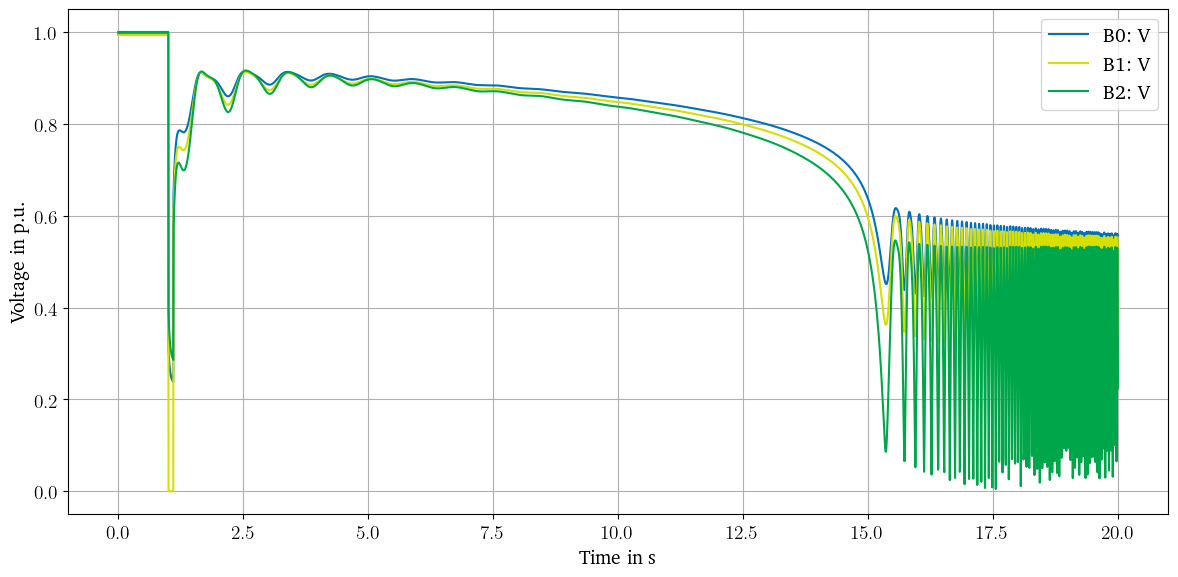

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(t, recorder[0, :, 0], label=record_list[0])
plt.plot(t, recorder[0, :, 1], label=record_list[1])
plt.plot(t, recorder[0, :, 2], label=record_list[2])

plt.legend()
plt.grid()
plt.xlabel("Time in s")
plt.ylabel("Voltage in p.u.")

plt.show()

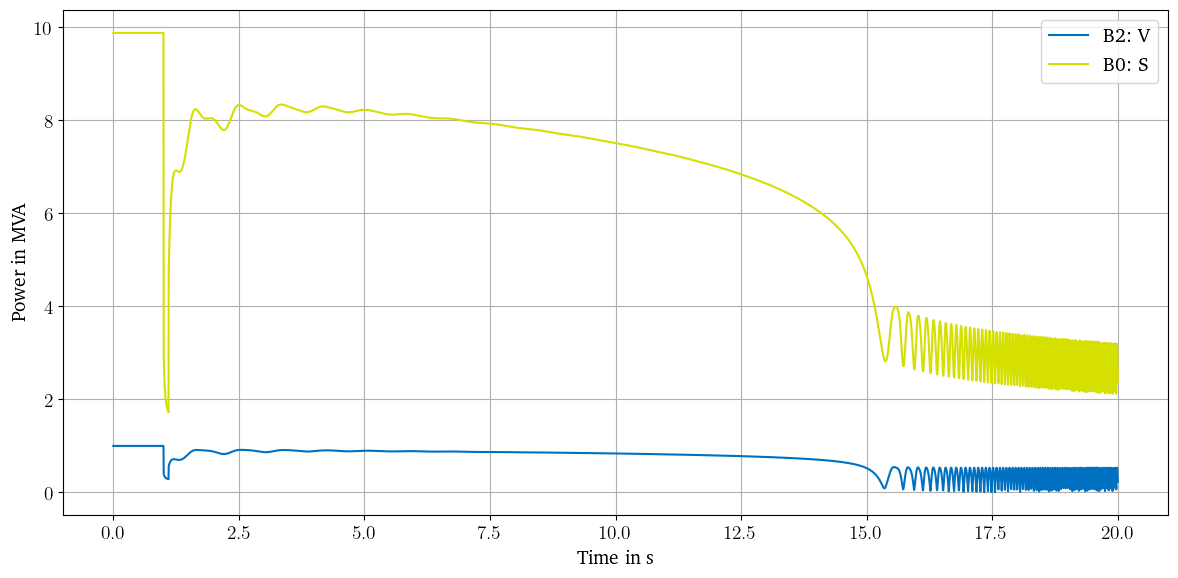

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(t, recorder[0, :, 2], label=record_list[2])
plt.plot(t, recorder[0, :, 3], label=record_list[3])

plt.legend()
plt.grid()
plt.xlabel("Time in s")
plt.ylabel("Power in MVA")

plt.show()

## Voltage Stability: Nose Curves

In [8]:
load_dict = {
    "p": np.linspace(0, 10000, 1000),
    "tan_phi": [0],
}
sim.verbose = False

nc = NoseCurve(load_model=simple_load, loading=load_dict, ps_sim=sim)

res_nc = nc.run_calculation(["B1"])["B1"]

/Users/maxikoehler/Documents/GitHub/diffpssi-ma-kohler/src/diffpssi/stability_lib/voltage.py:325: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


<Axes: title={'center': 'Nose Curves for Bus B1'}, xlabel='Active Power in MW', ylabel='Voltage in V'>

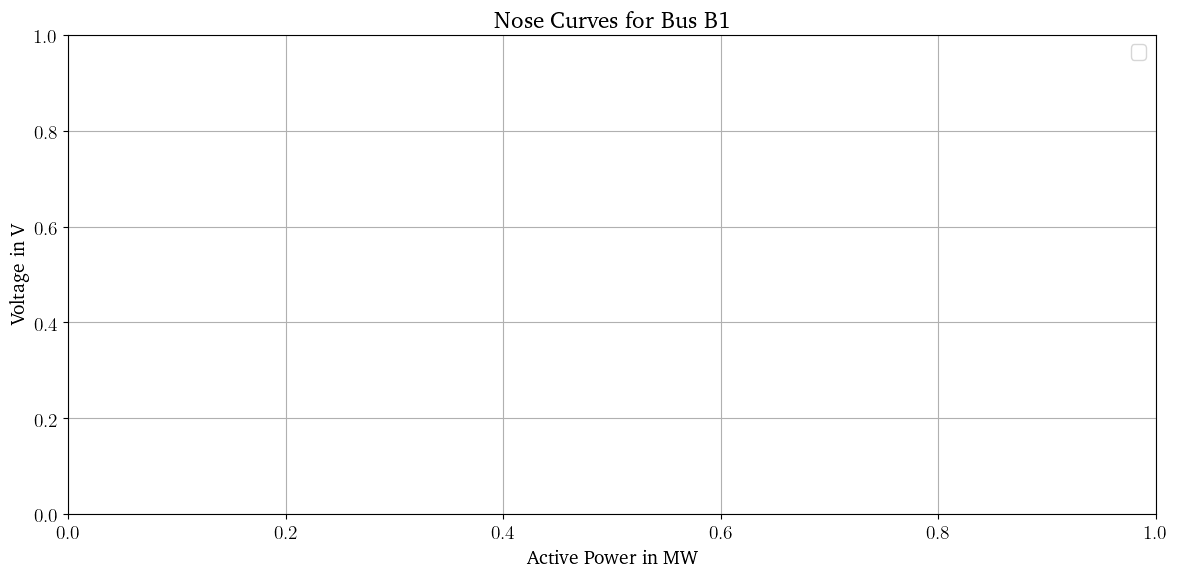

In [9]:
nc.plot_nose_curve(busses=["B1"])

## Adding Plot: FRT Curves

In [10]:
violation = ViolationIntegral(envelope="TVI")
violation.set_env_params(
    env_params={
        "beta": 0.05,
        "v_st": 0.9,
        "t_start": fault_end,
    }
)
integral_bus0 = violation.get_result(time=t, v_bb=recorder[0, :, 0])
integral_bus1 = violation.get_result(time=t, v_bb=recorder[0, :, 1])
integral_bus2 = violation.get_result(time=t, v_bb=recorder[0, :, 2])

env = violation.get_env(t)

print(integral_bus0)
print(integral_bus1)
print(integral_bus2)

2.2012132379992817
2.51444973819478
3.14754969606859


In [11]:
csi = 1 / 3 * (integral_bus0 + integral_bus1 + integral_bus2)

print(csi)

2.621070890754217


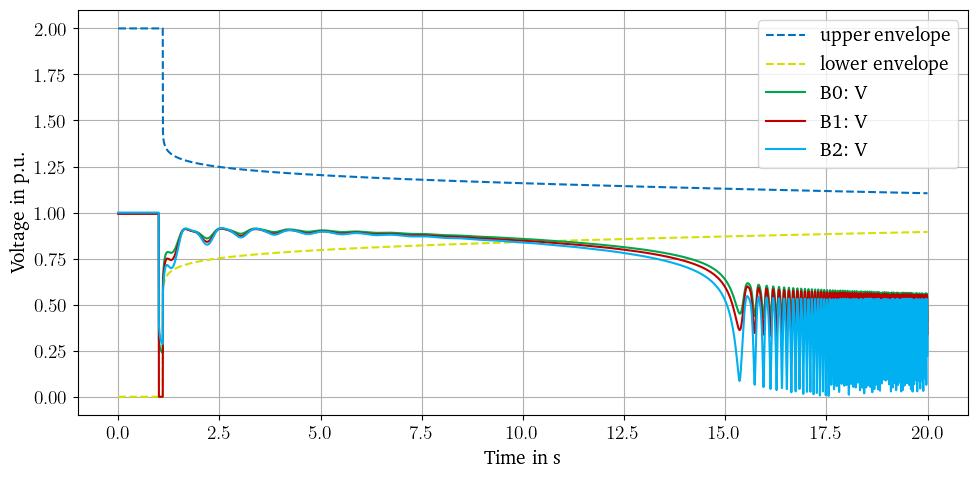

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(t, env[0], "--", label="upper envelope")
plt.plot(t, env[1], "--", label="lower envelope")

plt.plot(t, recorder[0, :, 0], label=record_list[0])
plt.plot(t, recorder[0, :, 1], label=record_list[1])
plt.plot(t, recorder[0, :, 2], label=record_list[2])

plt.legend()
plt.grid()
plt.xlabel("Time in s")
plt.ylabel("Voltage in p.u.")

# plt.xlim(1,5)

# plt.savefig('./plots/env_stable_example.pdf')

plt.show()

## Critical Times: Max Loading, FRT Cut, Envelope Cut

In [ ]:
crit_times = CrtiticalTimes(calculation_dict=None)
crit_times.add_env_data(time=t)

t_crit = crit_times.get_result(t, recorder[0, :, 0:2])

print(crit_times.results.keys())
print("FRT cuts: " + str(t_crit["bus_1"]["frt"]))
print("TVI cuts: " + str(t_crit["bus_1"]["tvi"]))

dict_keys(['bus_0', 'bus_1'])


KeyError: 'frt'